# 05 - Label Construction (Daily Frequency)

**Inputs**:
- `daily_features.parquet` -- daily features from 04
- `options_clean.parquet` -- cleaned options data

**Outputs**:
- `daily_modeling_data.parquet` -- daily features + monthly labels propagated to each trading day

**Label**: 3-class moneyness (ATM/OTM5/OTM10) -- best-performing moneyness bucket per ticker-month

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']

print(f"Universe: {UNIVERSE}")

Universe: ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']


## 1. Load Data

In [2]:
features = pd.read_parquet(PROCESSED / 'daily_features.parquet')
options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
daily_prices = pd.read_parquet(PROCESSED / 'daily_clean.parquet')

features['date'] = pd.to_datetime(features['date'])
options = options[options['symbol'].isin(UNIVERSE)].copy()
daily_prices = daily_prices[daily_prices['symbol'].isin(UNIVERSE)].copy()
daily_prices['date'] = pd.to_datetime(daily_prices['date'])

calls = options[options['call_put'] == 'CALL'].copy()
calls['expiration'] = pd.to_datetime(calls['expiration'])
calls['trade_date'] = pd.to_datetime(calls['trade_date'])
calls['dte'] = (calls['expiration'] - calls['trade_date']).dt.days

print(f"Daily features: {features.shape}")
print(f"Call options: {len(calls):,}")
print(f"Daily prices: {daily_prices.shape}")

Daily features: (51226, 29)
Call options: 560,976
Daily prices: (52486, 10)


## 2. Compute Monthly Best Moneyness Bucket

In [3]:
# Assign moneyness buckets
def assign_moneyness(delta):
    if 0.15 <= delta < 0.30: return 'OTM10'
    elif 0.30 <= delta < 0.45: return 'OTM5'
    elif 0.45 <= delta <= 0.60: return 'ATM'
    return None

calls['moneyness'] = calls['delta'].apply(assign_moneyness)
calls_valid = calls.dropna(subset=['moneyness']).copy()
# Keep DTE 7-120 for payoff computation
calls_valid = calls_valid[(calls_valid['dte'] >= 7) & (calls_valid['dte'] <= 120)].copy()

print(f"Valid moneyness contracts: {len(calls_valid):,}")
print(calls_valid['moneyness'].value_counts())

Valid moneyness contracts: 87,194
moneyness
OTM10    30630
ATM      29183
OTM5     27381
Name: count, dtype: int64


In [4]:
# Merge entry price
prices = daily_prices[['symbol', 'date', 'adjusted_close']].rename(
    columns={'adjusted_close': 'price'}).sort_values(['symbol', 'date'])

calls_valid = calls_valid.merge(
    prices.rename(columns={'date': 'trade_date', 'price': 'entry_price'}),
    on=['symbol', 'trade_date'], how='left'
)

# Merge exit price (per-symbol merge_asof)
daily_exit = prices.rename(columns={'date': 'expiration', 'price': 'exit_price'})
result_list = []
for sym in UNIVERSE:
    left = calls_valid[calls_valid['symbol'] == sym].sort_values('expiration')
    right = daily_exit[daily_exit['symbol'] == sym].sort_values('expiration')
    merged = pd.merge_asof(left, right[['expiration', 'exit_price']], on='expiration', direction='backward')
    result_list.append(merged)
calls_valid = pd.concat(result_list, ignore_index=True)

print(f"Contracts with entry price: {calls_valid['entry_price'].notna().sum():,}")
print(f"Contracts with exit price: {calls_valid['exit_price'].notna().sum():,}")

Contracts with entry price: 85,227
Contracts with exit price: 85,454


In [5]:
# Compute covered call payoff
calls_valid['premium'] = calls_valid['mark'].fillna((calls_valid['bid'] + calls_valid['ask']) / 2)
calls_valid['stock_pnl'] = np.minimum(calls_valid['exit_price'], calls_valid['strike']) - calls_valid['entry_price']
calls_valid['total_pnl'] = calls_valid['premium'] + calls_valid['stock_pnl']
calls_valid['return'] = calls_valid['total_pnl'] / calls_valid['entry_price']

# Filter outliers
calls_valid = calls_valid[(calls_valid['return'] > -0.5) & (calls_valid['return'] < 0.5)].copy()
calls_valid = calls_valid[(calls_valid['entry_price'] > 0) & (calls_valid['premium'] > 0)].copy()

print(f"After outlier filter: {len(calls_valid):,} contracts")
print(f"Return stats:")
print(calls_valid['return'].describe())

After outlier filter: 59,575 contracts
Return stats:
count    59575.000000
mean         0.167265
std          0.162746
min         -0.452860
25%          0.044947
50%          0.140855
75%          0.294301
max          0.499996
Name: return, dtype: float64


In [6]:
# Aggregate to monthly moneyness returns
calls_valid['year_month'] = calls_valid['trade_date'].dt.to_period('M')
moneyness_returns = calls_valid.groupby(['symbol', 'year_month', 'moneyness'])['return'].mean().reset_index()

# Find best moneyness per symbol-month
best_idx = moneyness_returns.groupby(['symbol', 'year_month'])['return'].idxmax()
best_moneyness = moneyness_returns.loc[best_idx][['symbol', 'year_month', 'moneyness', 'return']].copy()
best_moneyness = best_moneyness.rename(columns={'moneyness': 'best_moneyness', 'return': 'best_return'})

# Create numeric label
moneyness_map = {'ATM': 0, 'OTM5': 1, 'OTM10': 2}
best_moneyness['label_3'] = best_moneyness['best_moneyness'].map(moneyness_map)

print(f"Monthly labels: {len(best_moneyness):,}")
print(f"\nLabel distribution:")
print(best_moneyness['label_3'].value_counts().sort_index().rename({0:'ATM', 1:'OTM5', 2:'OTM10'}))
print(f"\nImbalance ratio: {best_moneyness['label_3'].value_counts().max() / best_moneyness['label_3'].value_counts().min():.1f}x")

Monthly labels: 1,391

Label distribution:
label_3
ATM      861
OTM5     239
OTM10    291
Name: count, dtype: int64

Imbalance ratio: 3.6x


## 3. Propagate Labels to Daily Features

In [7]:
# Each trading day gets the label of its month
features['year_month'] = features['date'].dt.to_period('M')

daily_modeling = features.merge(
    best_moneyness[['symbol', 'year_month', 'best_moneyness', 'best_return', 'label_3']],
    on=['symbol', 'year_month'],
    how='inner'
)

print(f"Daily features: {features.shape[0]:,}")
print(f"Daily with labels: {daily_modeling.shape[0]:,} ({daily_modeling.shape[0]/features.shape[0]*100:.1f}%)")
print(f"Date range: {daily_modeling['date'].min().date()} to {daily_modeling['date'].max().date()}")
print(f"\nLabel distribution (daily rows):")
for label, name in enumerate(['ATM', 'OTM5', 'OTM10']):
    count = (daily_modeling['label_3'] == label).sum()
    print(f"  {label} ({name}): {count:,} ({count/len(daily_modeling)*100:.1f}%)")

Daily features: 51,226
Daily with labels: 29,273 (57.1%)
Date range: 2008-02-01 to 2025-12-31

Label distribution (daily rows):
  0 (ATM): 18,152 (62.0%)
  1 (OTM5): 5,005 (17.1%)
  2 (OTM10): 6,116 (20.9%)


## 4. EDA on Labels

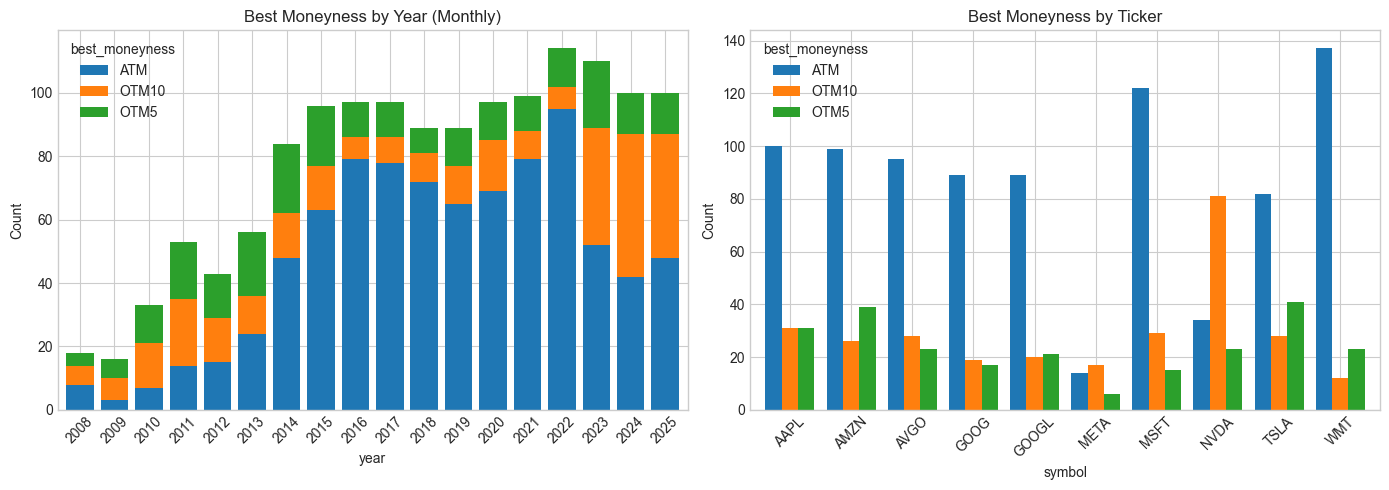

In [8]:
# Label distribution by year
daily_modeling['year'] = daily_modeling['date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly label counts
monthly_labels = best_moneyness.copy()
monthly_labels['year'] = monthly_labels['year_month'].dt.year
yearly = monthly_labels.groupby(['year', 'best_moneyness']).size().unstack(fill_value=0)
yearly.plot(kind='bar', stacked=True, ax=axes[0], width=0.8)
axes[0].set_title('Best Moneyness by Year (Monthly)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Per ticker
ticker_labels = monthly_labels.groupby(['symbol', 'best_moneyness']).size().unstack(fill_value=0)
ticker_labels.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Best Moneyness by Ticker')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Compute Class Weights

In [9]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])
# Use monthly labels for class weights (not inflated daily counts)
cw = compute_class_weight('balanced', classes=classes, y=best_moneyness['label_3'])
cw_dict = dict(zip(classes.tolist(), cw.tolist()))

print("Class weights:")
for label, name in enumerate(['ATM', 'OTM5', 'OTM10']):
    print(f"  {label} ({name}): {cw_dict[label]:.3f}")

with open(PROCESSED / 'class_weights.json', 'w') as f:
    json.dump({int(k): float(v) for k, v in cw_dict.items()}, f, indent=2)
print(f"\nSaved: {PROCESSED / 'class_weights.json'}")

Class weights:
  0 (ATM): 0.539
  1 (OTM5): 1.940
  2 (OTM10): 1.593

Saved: ../data/processed/class_weights.json


## 6. Save

In [10]:
daily_modeling.to_parquet(PROCESSED / 'daily_modeling_data.parquet', index=False)
print(f"Saved: {PROCESSED / 'daily_modeling_data.parquet'}")

# Also save monthly labels separately
best_moneyness.to_parquet(PROCESSED / 'monthly_labels.parquet', index=False)
print(f"Saved: {PROCESSED / 'monthly_labels.parquet'}")

print(f"\n{'='*60}")
print("DAILY LABEL CONSTRUCTION COMPLETE")
print(f"{'='*60}")
print(f"Tickers: {daily_modeling['symbol'].nunique()}")
print(f"Date range: {daily_modeling['date'].min().date()} to {daily_modeling['date'].max().date()}")
print(f"Daily rows: {len(daily_modeling):,}")
print(f"Monthly labels: {len(best_moneyness):,}")
print(f"Classes: 3 (ATM=0, OTM5=1, OTM10=2)")

Saved: ../data/processed/daily_modeling_data.parquet
Saved: ../data/processed/monthly_labels.parquet

DAILY LABEL CONSTRUCTION COMPLETE
Tickers: 10
Date range: 2008-02-01 to 2025-12-31
Daily rows: 29,273
Monthly labels: 1,391
Classes: 3 (ATM=0, OTM5=1, OTM10=2)
